In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
def LoadData_Explore(filename):
    df = None
    try:
        df = pd.read_csv(filename)
        print("Data loaded into dataframe successfully!!")
        print("Please find the shape of the data as follows:")
        display(df.shape)
        print("Please find the first 5 rows of data as follows:")
        display(df.head())
        print("Please find the last 5 rows of data as follows:")
        display(df.tail())
        print("Please find the information on the data and data type as follows:")
        display(df.info())
        print("Please find the descriptive stats for numeric columns as follows:")
        display(df.describe())
        #print("Please find the descriptive stats for non numeric columns as follows:")
        #display(df.describe(include='O'))
        print("Lets check the data types for all the columns in data:")
        display(df.dtypes)    
    except FileNotFoundError:
        print(f"Error: {filename} not found!")
    return df 

In [3]:
#Load data from csv file
df = LoadData_Explore('HousingData.csv')


Data loaded into dataframe successfully!!
Please find the shape of the data as follows:


(20, 3)

Please find the first 5 rows of data as follows:


,Area (sq ft),Bedrooms,House Price ($)
0,750,1,280000
1,820,2,300000
2,900,2,325000
3,1000,2,350000
4,1150,3,400000


Please find the last 5 rows of data as follows:


,Area (sq ft),Bedrooms,House Price ($)
15,2800,5,780000
16,3000,6,830000
17,3200,6,880000
18,3500,6,940000
19,3800,6,1000000


Please find the information on the data and data type as follows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Area (sq ft)     20 non-null     int64
 1   Bedrooms         20 non-null     int64
 2   House Price ($)  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


None

Please find the descriptive stats for numeric columns as follows:


,Area (sq ft),Bedrooms,House Price ($)
count,20.000000,20.000000,20.000000
mean,1998.500000,3.950000,593500.000000
std,925.937789,1.538112,218777.103584
min,750.000000,1.000000,280000.000000
25%,1225.000000,3.000000,422500.000000
50%,1900.000000,4.000000,577500.000000
75%,2650.000000,5.000000,750000.000000
max,3800.000000,6.000000,1000000.000000


Lets check the data types for all the columns in data:


Area (sq ft)       int64
Bedrooms           int64
House Price ($)    int64
dtype: object

In [4]:
#Lets split train and test data
y = df['House Price ($)']
x = df.drop('House Price ($)', axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
#As the features are on different scales data need to be scaled
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_sc = scaler.transform(x_train)
x_test_sc = scaler.transform(x_test)

In [6]:
#Lets fit the data to Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
#Lets predict on the test daya
y_train_pred = lin_reg.predict(x_train)
y_test_pred = lin_reg.predict(x_test)

In [8]:
#Lets check the metrics for the train & test data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Training MSE:{mse_train}")
print(f"Testing MSE:{mse_test}")
print(f"Training R2 Score:{r2_train}")
print(f"Testing R2 Score:{r2_test}")

Training MSE:21933155.935303785
Testing MSE:88284861.47174175
Training R2 Score:0.9994218548461745
Testing R2 Score:0.998810177069114


#Lets plot the 3D to visualize the House Pricing Data

In [9]:
import plotly.graph_objects as go 

#Extract Area & Bedrooms
area = x_train.iloc[:,0]
bedrooms = x_train.iloc[:,1]
prices = y_train 

#In order to plot 3D graph we need area & bedroom Min & Max Values as well as Mesh grid
area_range = np.linspace(area.min(), area.max(),30)
bedroom_range = np.linspace(bedrooms.min(), bedrooms.max(), 30)
A, B = np.meshgrid(area_range, bedroom_range)

#Define grid points and prediction plane
grid_points = np.column_stack((A.ravel(), B.ravel()))
predicted_plane = lin_reg.predict(grid_points).reshape(A.shape)

#Define Ploty Figure
fig = go.Figure()

#Scatter Points
fig.add_trace(go.Scatter3d( x=area, y=bedrooms, z=prices,
    mode='markers',marker=dict(size=5, color='blue'),
    name='Training Data'))

#Define Regression plane
fig.add_trace(go.Surface(x=A, y=B, z=predicted_plane,
              colorscale='Viridis', opacity=0.6, name ='Regression Plane'))

#Define the plot layout
fig.update_layout(
    title="3D Regression model for house price prediction",
    scene=dict(
        xaxis_title="Area (sq ft)",
        yaxis_title="Bedrooms",
        zaxis_title="Price($)"
    ),
    width=700,
    height=600
)

fig.show()

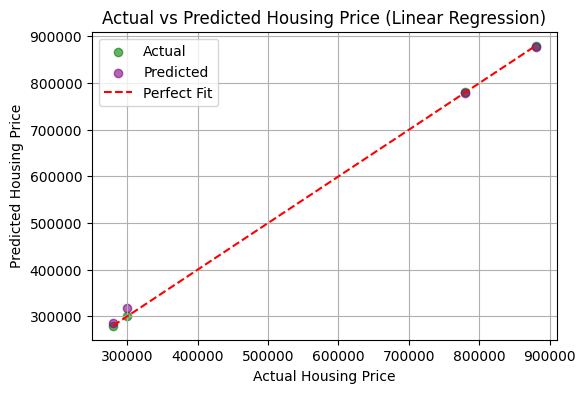

In [10]:
# Predict on test data & plot the y_test & y_test_pred
y_test_pred = lin_reg.predict(x_test)

plt.figure(figsize=(6,4))

# Actual points (y_test vs y_test)
plt.scatter(y_test, y_test, color='green', label='Actual', alpha=0.6)

# Predicted points (y_test vs y_test_pred)
plt.scatter(y_test, y_test_pred, color='purple', label='Predicted', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

plt.xlabel("Actual Housing Price")
plt.ylabel("Predicted Housing Price")
plt.title("Actual vs Predicted Housing Price (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()